<a href="https://colab.research.google.com/github/JWasonga/Python-Data-Analysis-and-Visualization/blob/main/Ordinary_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analyzing Kenya's GDP Growth Over time (1960 to Date)

##Data Loading and cleaning

In [2]:
from google.colab import files
uploaded = files.upload()

Saving transposed.xlsx to transposed.xlsx


In [5]:
import pandas as pd
df = pd.read_excel('transposed.xlsx')
df

,year,gdp,gcf,labor
0,1990,8572359168,2071432832,73.783
1,1991,8151489024,1709409152,73.723
2,1992,8209120768,1389052160,73.657
3,1993,5751786496,1012914624,73.588
4,1994,7148148736,1379109632,73.518
5,1995,9046320128,1973885440,73.454
6,1996,12045864960,1807340288,73.393
7,1997,13115764736,1985856384,73.320
8,1998,14093999104,2352671232,73.254
9,1999,12896010240,2001643264,73.175


In [8]:
df.isnull().sum()

,0
year,0
gdp,0
gcf,0
labor,0


In [9]:
df.describe()

,year,gdp,gcf,labor
count,35.000000,3.500000e+01,3.500000e+01,35.000000
mean,2007.000000,4.498477e+10,8.820464e+09,72.644029
std,10.246951,3.810350e+10,7.457712e+09,2.286523
min,1990.000000,5.751786e+09,1.012915e+09,67.448000
25%,1998.500000,1.294101e+10,2.036538e+09,73.214500
50%,2007.000000,3.195819e+10,6.537681e+09,73.518000
75%,2015.500000,7.246780e+10,1.622531e+10,73.870000
max,2024.000000,1.203396e+11,2.236994e+10,74.697000


## Performing Statistical Tests (OLS assumptions)

To analyze the dataset further, we will perform several statistical tests to ensure OLS assumptions are upheld:

1.  **Heteroscedasticity Test**: To check if the variance of the errors from a regression model is constant across all levels of the independent variables.
2.  **Multicollinearity Test**: To detect high correlation among independent variables in a regression model.
3.  **Normality Test**: To determine if the residuals from a regression model are normally distributed.
4.  **Autocorrelation Test**: To check if there is a correlation between a time series and a lagged version of itself (typically on regression residuals).

In [10]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# Define the model formula: GDP as dependent, GCF and Labor as independent variables
formula = 'gdp ~ gcf + labor'

# Fit the OLS model
model = smf.ols(formula, data=df).fit()

print(model.summary())
residuals = model.resid

                            OLS Regression Results                            
Dep. Variable:                    gdp   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1224.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           5.92e-31
Time:                        03:05:01   Log-Likelihood:                -825.75
No. Observations:                  35   AIC:                             1658.
Df Residuals:                      32   BIC:                             1662.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.92e+11   3.33e+10      5.759      0.0

### 1. Heteroscedasticity Test (Breusch-Pagan Test)

**Purpose**: The Breusch-Pagan test checks for heteroscedasticity, which means the variance of the errors is not constant across all levels of the independent variables. A significant p-value (typically < 0.05) indicates the presence of heteroscedasticity.

**Interpretation**:
*   **Null Hypothesis (H0)**: Homoscedasticity is present (variance of errors is constant).
*   **Alternative Hypothesis (H1)**: Heteroscedasticity is present (variance of errors is not constant).

In [11]:
# Perform Breusch-Pagan test
# exog_het are the independent variables for the test
exog_het = model.model.exog # This includes the constant if added by smf.ols

# Ensure we pass the residuals and the independent variables to the test
# The first value is the LM statistic, the second is the p-value
bp_test = sms.het_breuschpagan(residuals, exog_het)

print(f"Breusch-Pagan Test Statistic: {bp_test[0]:.4f}")
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.4f}")

if bp_test[1] < 0.05:
    print("Conclusion: Heteroscedasticity is present (reject H0).")
else:
    print("Conclusion: Homoscedasticity is present (fail to reject H0).")

Breusch-Pagan Test Statistic: 12.6587
Breusch-Pagan Test p-value: 0.0018
Conclusion: Heteroscedasticity is present (reject H0).


### 2. Multicollinearity Test (Variance Inflation Factor - VIF)

**Purpose**: Multicollinearity occurs when independent variables are highly correlated with each other. VIF measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. A VIF value greater than 5 or 10 is often considered problematic.

**Interpretation**:
*   **VIF = 1**: No multicollinearity.
*   **1 < VIF < 5**: Moderate multicollinearity (generally acceptable).
*   **VIF >= 5 (or 10)**: High multicollinearity (potentially problematic).

In [12]:
# Prepare independent variables for VIF calculation
X = df[['gcf', 'labor']]
# Add a constant to the independent variables for VIF calculation
X = add_constant(X)

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF):")
print(vif_data)

# Check for high VIF values
high_vif_features = vif_data[vif_data['VIF'] >= 5]
if not high_vif_features.empty:
    print("\nConclusion: High multicollinearity detected for the following features:")
    display(high_vif_features)
else:
    print("\nConclusion: No significant multicollinearity detected (all VIF values are below 5).")

Variance Inflation Factor (VIF):
  feature          VIF
0   const  1953.599031
1     gcf     1.788327
2   labor     1.788327

Conclusion: High multicollinearity detected for the following features:


,feature,VIF
0,const,1953.599031


### 3. Normality Test (Shapiro-Wilk Test)

**Purpose**: The Shapiro-Wilk test assesses whether a sample comes from a normally distributed population. For regression models, we typically test the normality of the residuals. A significant p-value (typically < 0.05) suggests that the residuals are not normally distributed.

**Interpretation**:
*   **Null Hypothesis (H0)**: The residuals are normally distributed.
*   **Alternative Hypothesis (H1)**: The residuals are not normally distributed.

We will also visualize the distribution using a histogram and a Q-Q plot.

Shapiro-Wilk Test Statistic: 0.8713
Shapiro-Wilk Test p-value: 0.0007
Conclusion: Residuals are not normally distributed (reject H0).


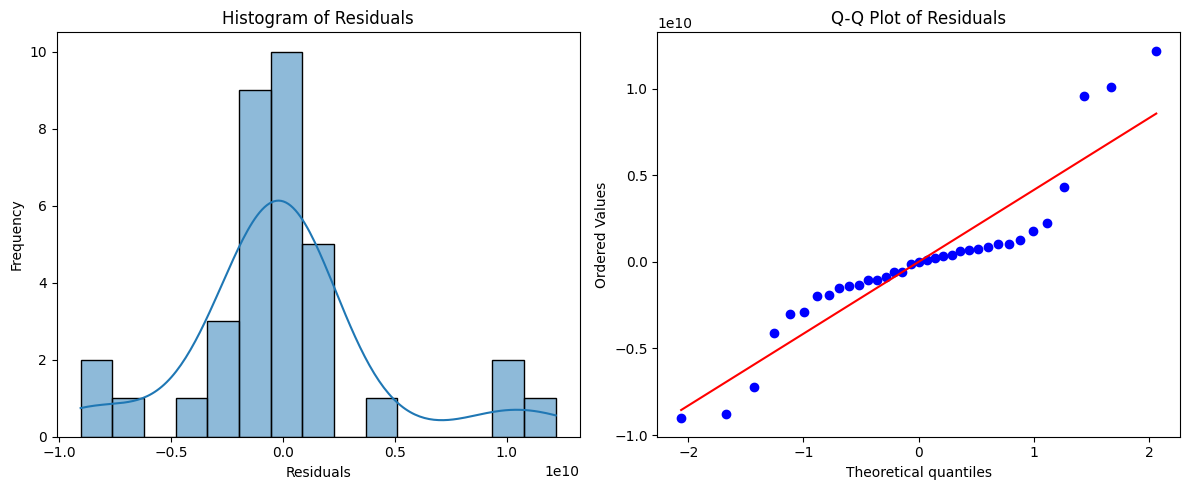

In [14]:
import seaborn as sns
# Perform Shapiro-Wilk test on residuals
shapiro_test = stats.shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.4f}")
print(f"Shapiro-Wilk Test p-value: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue < 0.05:
    print("Conclusion: Residuals are not normally distributed (reject H0).")
else:
    print("Conclusion: Residuals are normally distributed (fail to reject H0).")

# Visualize residuals distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

### 4. Autocorrelation Test (Durbin-Watson Test & ACF Plot)

**Purpose**: Autocorrelation (or serial correlation) occurs when the residuals are not independent of each other over time. The Durbin-Watson test checks for the presence of autocorrelation in the residuals of a regression analysis. A value around 2 indicates no autocorrelation, values below 2 suggest positive autocorrelation, and values above 2 suggest negative autocorrelation.

**Interpretation of Durbin-Watson statistic**:
*   **DW = 2**: No autocorrelation.
*   **DW < 2**: Positive autocorrelation.
*   **DW > 2**: Negative autocorrelation.

Durbin-Watson Statistic: 0.9334
Conclusion: Evidence of autocorrelation (may be positive or negative).


<Figure size 1000x500 with 0 Axes>

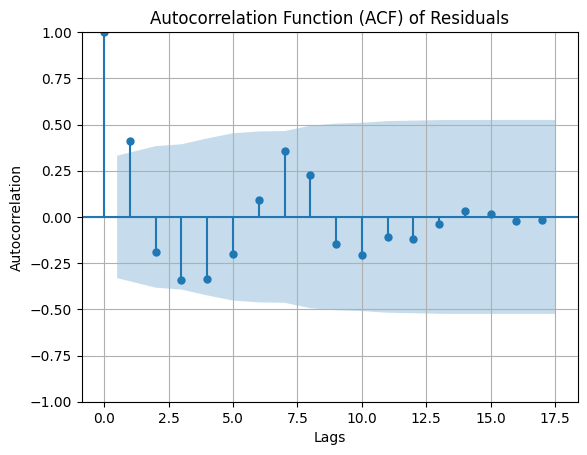

In [15]:
# Perform Durbin-Watson test on residuals
durbin_watson_stat = sms.durbin_watson(residuals)

print(f"Durbin-Watson Statistic: {durbin_watson_stat:.4f}")

if durbin_watson_stat < 1.5 or durbin_watson_stat > 2.5:
    print("Conclusion: Evidence of autocorrelation (may be positive or negative).")
elif durbin_watson_stat < 2:
    print("Conclusion: Evidence of positive autocorrelation.")
elif durbin_watson_stat > 2:
    print("Conclusion: Evidence of negative autocorrelation.")
else:
    print("Conclusion: No significant autocorrelation detected.")

# Plot Autocorrelation Function (ACF) of residuals
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=len(residuals)//2, alpha=0.05) # Plot up to half the length of residuals
plt.title('Autocorrelation Function (ACF) of Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

### 5. Structural Break Analysis (GDP Series)

**Purpose**: Structural breaks refer to sudden changes in the parameters of a time series model, indicating a shift in the underlying process generating the data. Detecting these breaks is crucial for accurate forecasting and policy analysis.

We will perform both a graphical display and an empirical test for structural breaks in the GDP series.

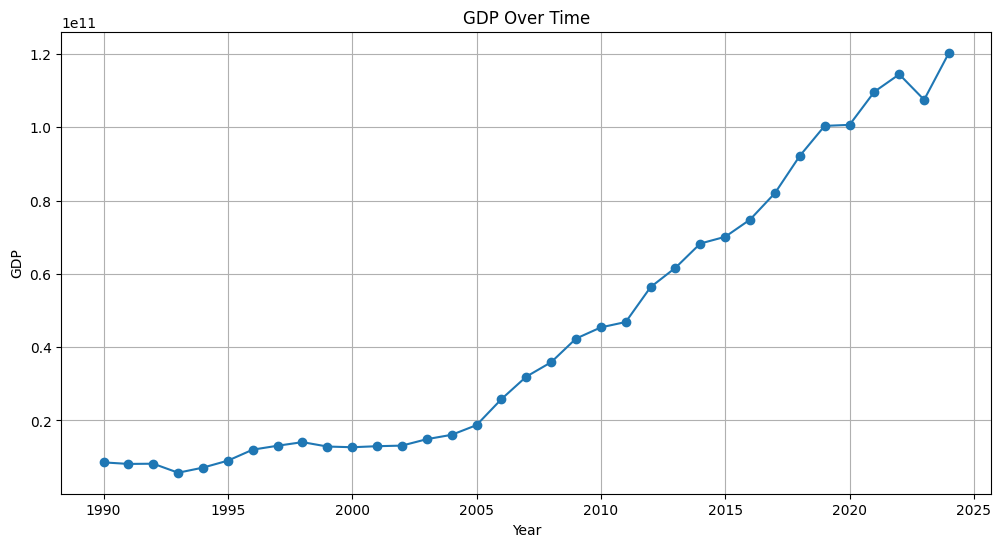

In [16]:
import matplotlib.pyplot as plt

# Plot GDP over time to visually inspect for structural breaks
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['gdp'], marker='o', linestyle='-')
plt.title('GDP Over Time')
plt.xlabel('Year')
plt.ylabel('GDP')
plt.grid(True)
plt.show()

#### Empirical Test for Structural Breaks (Chow Test)

**Purpose**: The Chow test is used to test whether the true regression coefficients in two separate groups of data are equal. It is commonly used to test for structural breaks at a known point in a time series. A significant p-value (typically < 0.05) suggests the presence of a structural break.

**Interpretation**:
*   **Null Hypothesis (H0)**: No structural break (the coefficients are the same across the two periods).
*   **Alternative Hypothesis (H1)**: A structural break exists (the coefficients are different across the two periods).

From the plot, there appears to be an acceleration in GDP growth around the late 2000s. Let's select the year 2008 (index 18) as a potential breakpoint for the Chow test.

In [17]:
from statsmodels.stats.api import het_goldfeldquandt # A different test, but useful in context
from statsmodels.regression.linear_model import OLS

# Define the breakpoint (e.g., year 2008, which is index 18)
break_year = 2008
break_index = df[df['year'] == break_year].index[0]

# Split the data into two periods based on the breakpoint
df_pre = df.iloc[:break_index]
df_post = df.iloc[break_index:]

# Define the regression formula
formula = 'gdp ~ gcf + labor'

# Perform OLS regression on the full dataset (unrestricted model)
model_full = smf.ols(formula, data=df).fit()
ssr_full = model_full.ssr # Sum of squared residuals for the full model
df_full = model_full.df_resid

# Perform OLS regression on the pre-break dataset
model_pre = smf.ols(formula, data=df_pre).fit()
ssr_pre = model_pre.ssr

# Perform OLS regression on the post-break dataset
model_post = smf.ols(formula, data=df_post).fit()
ssr_post = model_post.ssr

# Calculate the Chow test statistic
# F = ((SSR_full - (SSR_pre + SSR_post)) / k) / ((SSR_pre + SSR_post) / (n - 2k))
# k = number of parameters (including intercept) = 3 (gdp ~ const + gcf + labor)
# n = total number of observations = 35

k = model_full.df_model + 1 # Number of parameters (coefficients + intercept)
n = len(df)

chow_numerator = (ssr_full - (ssr_pre + ssr_post)) / k
chow_denominator = (ssr_pre + ssr_post) / (n - 2 * k)

# Check for division by zero or negative denominator
if chow_denominator <= 0 or (n - 2 * k) <= 0:
    print(f"Cannot perform Chow test for breakpoint at year {break_year}. Not enough observations in one or both sub-samples.")
else:
    chow_statistic = chow_numerator / chow_denominator
    # Degrees of freedom for F-distribution
    df1 = k
    df2 = n - 2 * k

    # Calculate p-value
    p_value = 1 - stats.f.cdf(chow_statistic, df1, df2)

    print(f"\nChow Test for structural break at year {break_year}:")
    print(f"F-statistic: {chow_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: A structural break is present (reject H0).")
    else:
        print("Conclusion: No significant structural break detected (fail to reject H0).")


Chow Test for structural break at year 2008:
F-statistic: 1.2042
P-value: 0.3257
Conclusion: No significant structural break detected (fail to reject H0).
